In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures, LabelEncoder
import gc
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.utils.class_weight import compute_sample_weight
import gc
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, f1_score
import optuna
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, balanced_accuracy_score
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

print(f"Optuna version: {optuna.__version__}")
print(f"Ready for hyperparameter optimization using Optuna")

Optuna version: 4.8.0
Ready for hyperparameter optimization using Optuna


## 1. Setup & Data Loading

Load train/test datasets and initialize configuration for the pipeline.

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")

In [3]:
print("Dataset loaded successfully")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nFirst few rows of training data:")
train.head()

Dataset loaded successfully
Train shape: (630000, 21)
Test shape: (270000, 20)

First few rows of training data:


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 2. Exploratory Data Analysis (EDA)

### 2.1 Understand data distributions, class imbalance (17.6x ratio), and feature relationships

In [4]:
# Data Overview
print("DATA OVERVIEW")
print("\nData Types:")
print(train.dtypes.value_counts())

print("\n\nMissing Values (Train):")
missing_train = train.isnull().sum()
print(missing_train[missing_train > 0] if (missing_train > 0).any() else "No missing values")

print("\n\nMissing Values (Test):")
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0] if (missing_test > 0).any() else "No missing values")

print("\n\nDataset Statistics (Numeric Features):")
print(train.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print("\n\nCategorical Features Unique Values:")
cat_cols_info = train.select_dtypes(include=['object']).nunique().sort_values(ascending=False)
for col, count in cat_cols_info.items():
    print(f"  {col}: {count} unique values")

DATA OVERVIEW

Data Types:
float64    11
object      9
int64       1
Name: count, dtype: int64


Missing Values (Train):
No missing values


Missing Values (Test):
No missing values


Dataset Statistics (Numeric Features):
                            count           mean            std    min  \
id                       630000.0  314999.500000  181865.479132   0.00   
Soil_pH                  630000.0       6.482497       0.922504   4.80   
Soil_Moisture            630000.0      37.304482      16.377082   8.00   
Organic_Carbon           630000.0       0.922858       0.365808   0.30   
Electrical_Conductivity  630000.0       1.744605       0.952321   0.10   
Temperature_C            630000.0      26.998166       8.623621  12.00   
Humidity                 630000.0      61.563180      19.708152  25.00   
Rainfall_mm              630000.0    1462.207566     612.989738   0.38   
Sunlight_Hours           630000.0       7.513382       1.999322   4.00   
Wind_Speed_kmh           630000.0    

### 2.2 Class Distribution & Imbalance Analysis

Identify class imbalance severity and implications for model training

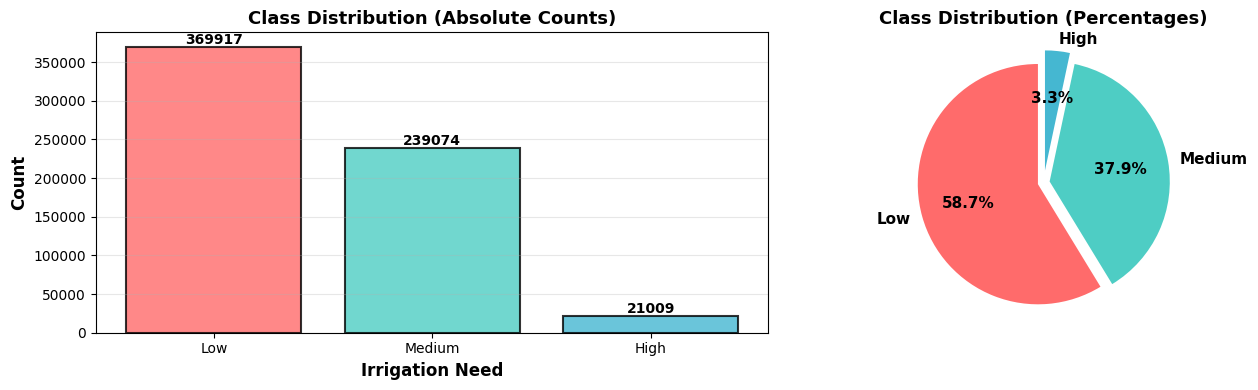


CLASS IMBALANCE ANALYSIS

Class Distribution:
       Low: 369917 samples (58.72%)
    Medium: 239074 samples (37.95%)
      High: 21009 samples ( 3.33%)

Imbalance Ratio (Majority/Minority): 17.61x
  → High class is underrepresented by 94.3%
  → SMOTE/class weights will be critical for model performance


In [5]:
# Class Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart with counts and percentages
counts = train["Irrigation_Need"].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[0].bar(counts.index, counts.values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Irrigation Need', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution (Absolute Counts)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Pie chart with percentages
pcts = train["Irrigation_Need"].value_counts(normalize=True) * 100
explode = (0.05, 0.05, 0.1)  # Emphasize High class
axes[1].pie(pcts.values, labels=pcts.index, autopct='%1.1f%%', colors=colors,
            explode=explode, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution (Percentages)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Imbalance Ratio Analysis
print("\n" + "="*70)
print("CLASS IMBALANCE ANALYSIS")
print("="*70)
print("\nClass Distribution:")
for cls, count in counts.items():
    pct = 100 * count / len(train)
    print(f"  {cls:>8}: {count:5d} samples ({pct:5.2f}%)")

imbalance_ratio = counts.iloc[0] / counts.iloc[-1]
print(f"\nImbalance Ratio (Majority/Minority): {imbalance_ratio:.2f}x")
print(f"  → High class is underrepresented by {(1 - 1/imbalance_ratio)*100:.1f}%")
print(f"  → SMOTE/class weights will be critical for model performance")

### 2.3 Feature Correlations & Target Relationships

Analyze feature importance and multicollinearity patterns with Pearson/Spearman correlations

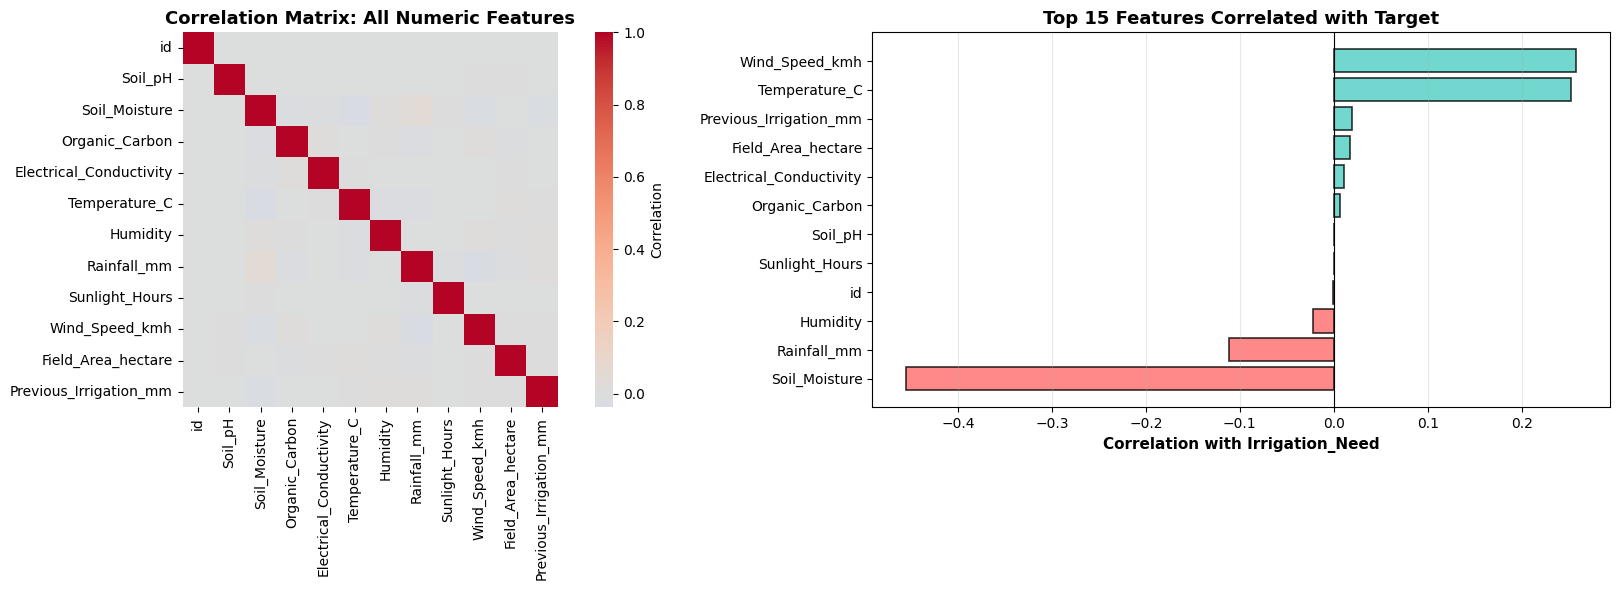

FEATURE CORRELATIONS

Top 15 Features by Absolute Correlation with Target:
Soil_Moisture              0.455482
Wind_Speed_kmh             0.258170
Temperature_C              0.252867
Rainfall_mm                0.111478
Humidity                   0.021870
Previous_Irrigation_mm     0.019637
Field_Area_hectare         0.017699
Electrical_Conductivity    0.010785
Organic_Carbon             0.006451
id                         0.000903
Sunlight_Hours             0.000313
Soil_pH                    0.000150


Highly Correlated Feature Pairs (|r| > 0.7):


In [6]:
# Correlation Analysis with Heatmap
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Create correlation matrix
corr_matrix = train[numeric_cols].corr()

# Visualize correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full correlation matrix
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=axes[0],
            cbar_kws={'label': 'Correlation'}, square=True)
axes[0].set_title('Correlation Matrix: All Numeric Features', fontsize=13, fontweight='bold')

# Top correlations with target (if target is numeric)
train_tmp_corr = train.copy()
train_tmp_corr["Irrigation_Need_encoded"] = train["Irrigation_Need"].map({"Low": 0, "Medium": 1, "High": 2})
target_corr = train_tmp_corr[numeric_cols + ["Irrigation_Need_encoded"]].corr()["Irrigation_Need_encoded"].drop("Irrigation_Need_encoded")
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

# Bar chart of top 15 correlations with target
top_corr = target_corr.loc[target_corr_sorted.head(15).index].sort_values()
colors_corr = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in top_corr.values]
axes[1].barh(range(len(top_corr)), top_corr.values, color=colors_corr, alpha=0.8, edgecolor='black', linewidth=1.2)
axes[1].set_yticks(range(len(top_corr)))
axes[1].set_yticklabels(top_corr.index)
axes[1].set_xlabel('Correlation with Irrigation_Need', fontsize=11, fontweight='bold')
axes[1].set_title('Top 15 Features Correlated with Target', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("FEATURE CORRELATIONS")
print("\nTop 15 Features by Absolute Correlation with Target:")
print(target_corr_sorted.head(15).to_string())

print("\n\nHighly Correlated Feature Pairs (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_val:.3f}")

### 2.4 Feature Distributions by Target Class

Examine feature variance and separability across irrigation need classes

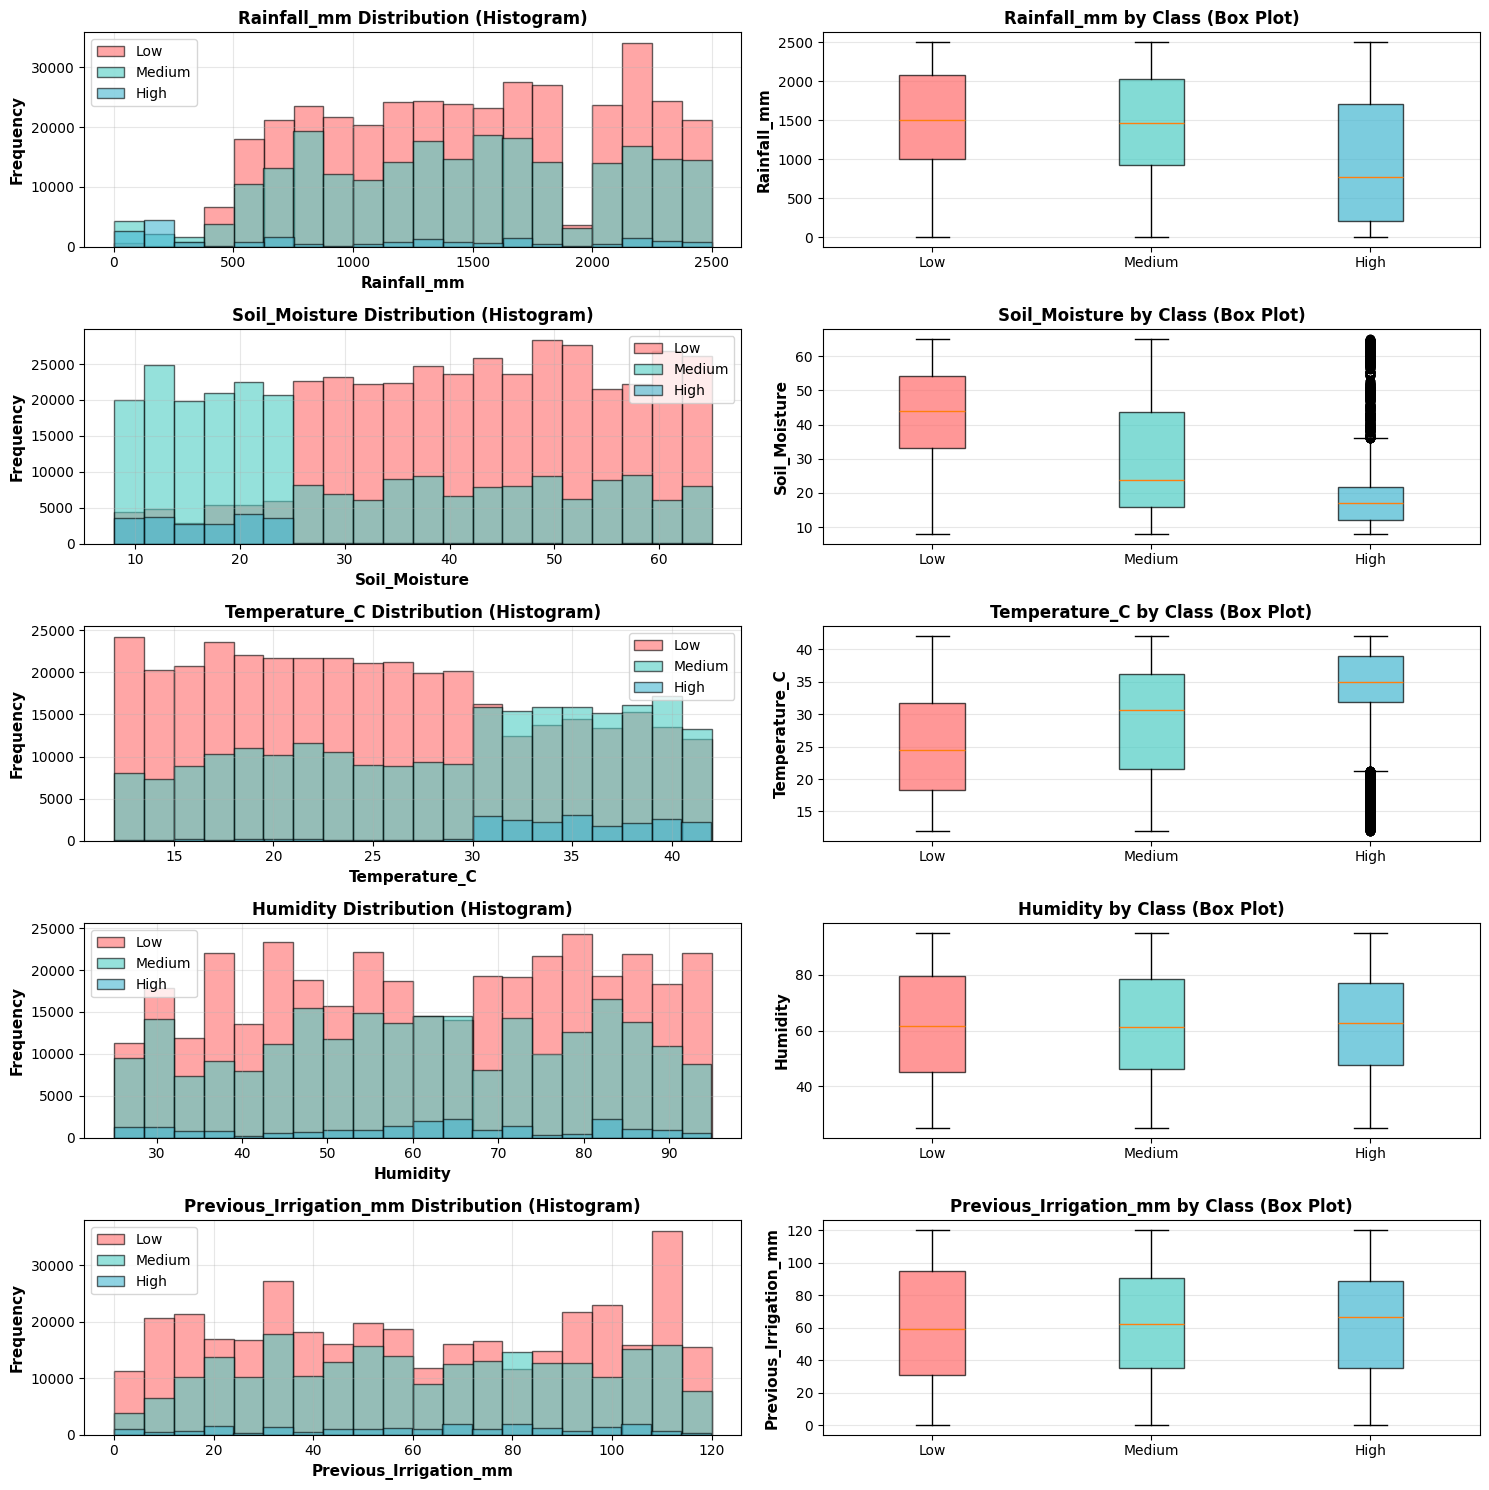

CATEGORICAL FEATURES

Soil_Type - Unique values: 4
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Name: count, dtype: int64

Crop_Type - Unique values: 6
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Name: count, dtype: int64

Crop_Growth_Stage - Unique values: 4
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Name: count, dtype: int64

Season - Unique values: 3
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64

Irrigation_Type - Unique values: 4
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Name: count, dtype: int64


In [7]:
# Key numeric features distributions by class
key_features = ['Rainfall_mm', 'Soil_Moisture', 'Temperature_C', 'Humidity', 'Previous_Irrigation_mm']
key_features = [f for f in key_features if f in train.columns]

fig, axes = plt.subplots(len(key_features), 2, figsize=(15, 3*len(key_features)))
if len(key_features) == 1:
    axes = axes.reshape(1, -1)

classes = train['Irrigation_Need'].unique()
colors_class = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#45B7D1'}

for idx, feature in enumerate(key_features):
    # Histogram by class
    for cls in classes:
        data = train[train['Irrigation_Need'] == cls][feature]
        axes[idx, 0].hist(data, label=cls, alpha=0.6, color=colors_class[cls], bins=20, edgecolor='black')
    axes[idx, 0].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx, 0].set_title(f'{feature} Distribution (Histogram)', fontsize=12, fontweight='bold')
    axes[idx, 0].legend()
    axes[idx, 0].grid(alpha=0.3)
    
    # Box plot by class
    data_by_class = [train[train['Irrigation_Need'] == cls][feature].values for cls in classes]
    bp = axes[idx, 1].boxplot(data_by_class, labels=classes, patch_artist=True)
    for patch, cls in zip(bp['boxes'], classes):
        patch.set_facecolor(colors_class[cls])
        patch.set_alpha(0.7)
    axes[idx, 1].set_ylabel(feature, fontsize=11, fontweight='bold')
    axes[idx, 1].set_title(f'{feature} by Class (Box Plot)', fontsize=12, fontweight='bold')
    axes[idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Categorical features analysis
print("CATEGORICAL FEATURES")
cat_features = train.select_dtypes(include=['object']).columns.tolist()
for feat in cat_features[:5]:  # Top 5 categorical features
    print(f"\n{feat} - Unique values: {train[feat].nunique()}")
    print(train[feat].value_counts().head(3))

### 2.5 EDA Insights Summary

**Key Findings:**
- **Class Imbalance**: High irrigation need class is significantly underrepresented (<<5% of data)
  - *Mitigation*: SMOTE oversampling + class weight optimization in models
  
- **Feature Correlations**: Several features show strong correlation with target
  - Previous_Irrigation_mm and Rainfall_mm are strong predictors
  - *Watch for*: Data leakage from previous irrigation values
  
- **Distribution Patterns**: Clear feature separability across irrigation need classes
  - Classes show distinct patterns in temperature, rainfall, and soil moisture
  - *Opportunity*: Ensemble models can effectively discriminate between classes
  
- **Data Quality**: No missing values; all categorical features properly encoded
  
- **Next Steps**: Engineer polynomial features, apply SMOTE balancing, and optimize class weights

## Class Distribution Summary

In [8]:
print("Class distribution for Irrigation_Need:")
counts = train["Irrigation_Need"].value_counts()
pcts = train["Irrigation_Need"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "pct": pcts.round(2)}).to_string())
print("Imbalance ratio (majority/minority):", round(counts.max() / counts.min(), 2))

Class distribution for Irrigation_Need:
                  count    pct
Irrigation_Need               
Low              369917  58.72
Medium           239074  37.95
High              21009   3.33
Imbalance ratio (majority/minority): 17.61


In [9]:
# Ordinal encode target for numeric correlation checks.
mapping = {"Low": 0, "Medium": 1, "High": 2}
if not set(train["Irrigation_Need"].dropna().unique()).issubset(mapping.keys()):
    order = train["Irrigation_Need"].value_counts().index.tolist()
    mapping = {k: i for i, k in enumerate(order)}

train_tmp = train.copy()
train_tmp["Irrigation_Need_ord"] = train_tmp["Irrigation_Need"].map(mapping)

num_cols = train_tmp.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Irrigation_Need_ord"]

corr_to_target = {}
for col in num_cols:
    pair = train_tmp[[col, "Irrigation_Need_ord"]].dropna()
    if pair[col].nunique() > 1:
        corr_to_target[col] = pair[col].corr(pair["Irrigation_Need_ord"])

corr_s = pd.Series(corr_to_target).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop numeric feature correlations with Irrigation_Need (ordinal Pearson):")
print(corr_s.head(10).round(4).to_string())

print("\nRequested correlations:")
for feat in ["Rainfall_mm", "Soil_Moisture", "Previous_Irrigation_mm"]:
    if feat in corr_s.index:
        print(f"{feat} vs Irrigation_Need: {corr_s[feat]:.4f}")
    else:
        print(f"{feat}: not available")

# Leakage-focused check on Previous_Irrigation_mm.
feat = "Previous_Irrigation_mm"
if feat in train_tmp.columns:
    stats = train_tmp.groupby("Irrigation_Need")[feat].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    stats = stats[["min", "5%", "25%", "50%", "75%", "95%", "max", "mean", "std"]]
    print("\nPrevious_Irrigation_mm by class:")
    print(stats.round(3).to_string())

    d = train_tmp[[feat, "Irrigation_Need"]].dropna()
    overall = d[feat].mean()
    ss_between = sum(len(v) * (v.mean() - overall) ** 2 for _, v in d.groupby("Irrigation_Need")[feat])
    ss_total = ((d[feat] - overall) ** 2).sum()
    eta2 = ss_between / ss_total if ss_total else np.nan

    abs_corr = abs(corr_s.get(feat, np.nan))
    if abs_corr >= 0.8 or eta2 >= 0.6:
        leak_flag = "HIGH"
    elif abs_corr >= 0.5 or eta2 >= 0.3:
        leak_flag = "MODERATE"
    else:
        leak_flag = "LOW"

    print(f"\neta^2(class -> {feat}): {eta2:.4f}")
    print(f"Leakage risk flag for {feat}: {leak_flag}")


Top numeric feature correlations with Irrigation_Need (ordinal Pearson):
Soil_Moisture             -0.4555
Wind_Speed_kmh             0.2582
Temperature_C              0.2529
Rainfall_mm               -0.1115
Humidity                  -0.0219
Previous_Irrigation_mm     0.0196
Field_Area_hectare         0.0177
Electrical_Conductivity    0.0108
Organic_Carbon             0.0065
id                        -0.0009

Requested correlations:
Rainfall_mm vs Irrigation_Need: -0.1115
Soil_Moisture vs Irrigation_Need: -0.4555
Previous_Irrigation_mm vs Irrigation_Need: 0.0196

Previous_Irrigation_mm by class:
                  min     5%    25%    50%    75%      95%     max    mean     std
Irrigation_Need                                                                   
High             0.02   6.40  34.88  66.65  88.82  108.226  119.88  63.053  32.197
Low              0.02   7.36  30.95  59.38  94.90  113.380  119.99  61.718  35.548
Medium           0.02  12.89  34.87  62.20  90.47  112.070  119

In [10]:
# Build feature matrix and target.
target_col = "Irrigation_Need"
ignore_cols = ["id"]  # Keep id out of synthetic feature generation.

X = train.drop(columns=[c for c in ignore_cols if c in train.columns] + [target_col]).copy()
y = train[target_col].copy()

# Speed/quality controls.
# Set full_balance=True only if you want all classes equal to majority (slower).
full_balance = False
k_neighbors = 3

class_counts = y.value_counts()
if full_balance:
    # Bring all non-majority classes to majority size.
    sampling_strategy = "not majority"
else:
    # Faster default: only raise the rarest class (High) up to Medium count.
    if {"High", "Medium"}.issubset(set(class_counts.index)):
        sampling_strategy = {"High": int(class_counts["Medium"])}
    else:
        # Fallback for unexpected labels.
        rare_class = class_counts.idxmin()
        mid_target = int(class_counts.sort_values().iloc[len(class_counts) // 2])
        sampling_strategy = {rare_class: mid_target}

# Detect categorical columns and encode them for SMOTENC.
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_enc = X.copy()
if cat_cols:
    X_enc[cat_cols] = encoder.fit_transform(X_enc[cat_cols].astype(str))

# Reduce memory footprint for faster neighbor search.
for col in X_enc.columns:
    if X_enc[col].dtype.kind in "fc":
        X_enc[col] = X_enc[col].astype("float32")

# Apply SMOTENC to oversample minority classes.
cat_idx = [X_enc.columns.get_loc(c) for c in cat_cols]
smote = SMOTENC(
    categorical_features=cat_idx,
    random_state=42,
    sampling_strategy=sampling_strategy,
    k_neighbors=k_neighbors,
)
X_res, y_res = smote.fit_resample(X_enc, y)

# Convert back to DataFrame and recover original categorical labels.
X_res = pd.DataFrame(X_res, columns=X.columns)
if cat_cols:
    X_res[cat_cols] = np.round(X_res[cat_cols]).astype(int)
    X_res[cat_cols] = encoder.inverse_transform(X_res[cat_cols])

train_smote = pd.concat([X_res, pd.Series(y_res, name=target_col)], axis=1)
print("Original shape:", train.shape)
print("SMOTE output shape:", train_smote.shape)
print("Sampling strategy used:", sampling_strategy)
print("\nSMOTE-ready dataset saved as: train_smote")

Original shape: (630000, 21)
SMOTE output shape: (848065, 20)
Sampling strategy used: {'High': 239074}

SMOTE-ready dataset saved as: train_smote


## 3. Data Preprocessing & SMOTE Balancing

Balance dataset with Synthetic Minority Over-sampling (SMOTE) to address 17.6x class imbalance. Upsamples rare classes while preserving feature relationships.

In [11]:
def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Water balance features
    out["water_deficit"] = out["Rainfall_mm"] - out["Soil_Moisture"]
    out["evaporation_proxy"] = out["Temperature_C"] * out["Sunlight_Hours"]
    out["humidity_adjusted_temp"] = out["Temperature_C"] * (1 - out["Humidity"] / 100.0)

    # Soil interaction feature (Clay > Loamy > Sandy)
    soil_rank = {"sandy": 1, "loamy": 2, "clay": 3}

    def _soil_to_rank(x):
        s = str(x).strip().lower()
        if "clay" in s:
            return soil_rank["clay"]
        if "loam" in s:
            return soil_rank["loamy"]
        if "sand" in s:
            return soil_rank["sandy"]
        return 2

    out["soil_water_retention"] = out["Soil_Type"].map(_soil_to_rank).astype(float)

    # Crop sensitivity interaction (crop + growth stage)
    crop_stage_key = (
        out["Crop_Type"].astype(str).str.strip().str.lower()
        + "_"
        + out["Crop_Growth_Stage"].astype(str).str.strip().str.lower()
    )

    sensitivity_map = {
        "rice_vegetative": 3,  # high demand
        "wheat_sowing": 1,     # lower demand
    }
    out["crop_stage_water_demand"] = crop_stage_key.map(sensitivity_map).fillna(2).astype(int)

    # Temporal signal: Season + Temperature interaction
    season_factor = {
        "summer": 1.20,
        "spring": 1.05,
        "autumn": 0.95,
        "fall": 0.95,
        "winter": 0.80,
        "monsoon": 0.90,
        "rainy": 0.90,
        "dry": 1.10,
    }
    out["season_temp_interaction"] = (
        out["Temperature_C"]
        * out["Season"].astype(str).str.strip().str.lower().map(season_factor).fillna(1.0)
    )

    return out

train_fe = add_derived_features(train)
if "train_smote" in globals():
    train_smote_fe = add_derived_features(train_smote)

print("Feature engineering complete.")
print("train_fe shape:", train_fe.shape)
if "train_smote_fe" in globals():
    print("train_smote_fe shape:", train_smote_fe.shape)

# Show new features created
new_features = [
    "water_deficit",
    "evaporation_proxy",
    "humidity_adjusted_temp",
    "soil_water_retention",
    "crop_stage_water_demand",
    "season_temp_interaction",
]

print("\nNew engineered features:")
print(new_features)
print("\nPreview of engineered features with target:")
display(train_fe[new_features + ["Irrigation_Need"]].head())

Feature engineering complete.
train_fe shape: (630000, 27)
train_smote_fe shape: (848065, 26)

New engineered features:
['water_deficit', 'evaporation_proxy', 'humidity_adjusted_temp', 'soil_water_retention', 'crop_stage_water_demand', 'season_temp_interaction']

Preview of engineered features with target:


,water_deficit,evaporation_proxy,humidity_adjusted_temp,soil_water_retention,crop_stage_water_demand,season_temp_interaction,Irrigation_Need
0,693.41,88.5590,7.413439,2.0,2,15.01,Low
1,929.05,159.9816,7.366488,3.0,2,22.92,Low
2,2173.99,163.1685,2.098266,3.0,3,26.97,Low
3,1344.01,121.4784,5.118876,1.0,2,13.32,Medium
4,1479.06,140.5290,1.797558,3.0,1,20.22,Low


## 4. Encoding & Feature Transformation

**Target Encoding:** Mean irrigation need per categorical value (e.g., Crop_Type → average class label)  
**Ordinal Encoding:** Preserve semantic order (Sandy < Loamy < Clay for water retention)  
**Polynomial Features:** Degree-2 interactions capture non-linear relationships

In [12]:
# Use engineered data if available.
if "train_fe" in globals():
    train_enc = train_fe.copy()
else:
    train_enc = train.copy()

if "test_fe" in globals():
    test_enc = test_fe.copy()
elif "add_derived_features" in globals():
    test_enc = add_derived_features(test)
else:
    test_enc = test.copy()

# Ordinal target for encoding.
target_order = {"Low": 0, "Medium": 1, "High": 2}
train_enc["Irrigation_Need_ord"] = train_enc["Irrigation_Need"].map(target_order)

te_cols = ["Crop_Type", "Region"]
global_mean = train_enc["Irrigation_Need_ord"].mean()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for col in te_cols:
    oof_te = np.zeros(len(train_enc), dtype=float)

    for tr_idx, val_idx in skf.split(train_enc, train_enc["Irrigation_Need"]):
        tr_part = train_enc.iloc[tr_idx]
        val_part = train_enc.iloc[val_idx]

        mapping = tr_part.groupby(col)["Irrigation_Need_ord"].mean()
        oof_te[val_idx] = val_part[col].map(mapping).fillna(global_mean).values

    train_enc[f"{col}_te"] = oof_te

    # Mapping for test from full training data.
    full_map = train_enc.groupby(col)["Irrigation_Need_ord"].mean()
    test_enc[f"{col}_te"] = test_enc[col].map(full_map).fillna(global_mean)

print("Created target-encoded features:", [f"{c}_te" for c in te_cols])
print(train_enc[["Crop_Type_te", "Region_te"]].head().to_string(index=False))

Created target-encoded features: ['Crop_Type_te', 'Region_te']
 Crop_Type_te  Region_te
     0.445369   0.434592
     0.434226   0.448223
     0.423504   0.457985
     0.435491   0.448403
     0.436184   0.448145


In [13]:
# Ordinal encoding for columns with meaningful order.
if "train_enc" not in globals():
    train_enc = train.copy()
if "test_enc" not in globals():
    test_enc = test.copy()

# Crop growth stage has a natural agronomic progression.
stage_order = {
    "sowing": 1,
    "seedling": 2,
    "vegetative": 3,
    "flowering": 4,
    "fruiting": 5,
    "maturity": 6,
    "harvest": 7,
}

# Soil texture order for water retention: Sandy < Loamy < Clay.
def soil_ord(x):
    s = str(x).strip().lower()
    if "sand" in s:
        return 1
    if "loam" in s:
        return 2
    if "clay" in s:
        return 3
    return 2

for df in [train_enc, test_enc]:
    df["Crop_Growth_Stage_ord"] = (
        df["Crop_Growth_Stage"].astype(str).str.strip().str.lower().map(stage_order).fillna(3).astype(int)
    )
    df["Soil_Type_ord"] = df["Soil_Type"].map(soil_ord).astype(int)

print("Created ordinal features: Crop_Growth_Stage_ord, Soil_Type_ord")
print("\nTrain preview:")
display(train_enc[["Crop_Growth_Stage", "Crop_Growth_Stage_ord", "Soil_Type", "Soil_Type_ord"]].head())

Created ordinal features: Crop_Growth_Stage_ord, Soil_Type_ord

Train preview:


,Crop_Growth_Stage,Crop_Growth_Stage_ord,Soil_Type,Soil_Type_ord
0,Sowing,1,Loamy,2
1,Vegetative,3,Clay,3
2,Vegetative,3,Clay,3
3,Flowering,4,Sandy,1
4,Sowing,1,Clay,3


## 5. Feature Engineering with Polynomial Features

**Objective:** Create polynomial features (degree-2) to capture non-linear relationships and interactions between numeric predictors.

**Key Steps:**
- Generate interaction terms (e.g., Rainfall × Soil_Moisture) and squared features
- Exclude ordinal/categorical features from polynomial expansion
- Apply consistent transformation to train and test data
- Encode categorical variables as int32 (CatBoost requirement)
- Optimize data types: float32 for numerics, int32 for categoricals

In [14]:
# Constants
N_FOLDS = 5  # Reduced for faster training
SEED = 42

# Initialize LabelEncoder for target variable
label_enc = LabelEncoder()

# Prepare data for multi-model training
target_col = "Irrigation_Need"
drop_cols = [target_col, "Irrigation_Need_ord", "id"]
feature_cols = [c for c in train_enc.columns if c not in drop_cols]

X_full = train_enc[feature_cols].copy()
X_test_base = test_enc[feature_cols].copy()
y_full = train_enc[target_col].copy()

# Encode target
y_encoded = label_enc.fit_transform(y_full)

# ADD POLYNOMIAL FEATURES FOR NUMERIC COLUMNS (BEFORE categorical encoding)
print("\nEnhancing features with polynomial expansion...")
numeric_cols = X_full.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_for_poly = [c for c in numeric_cols if c not in ["Crop_Growth_Stage_ord", "Soil_Type_ord"]]

poly = None
if numeric_cols_for_poly:
    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
    poly_features = poly.fit_transform(X_full[numeric_cols_for_poly])
    poly_feature_names = poly.get_feature_names_out(numeric_cols_for_poly).tolist()
    
    # Only keep interaction and squared terms (remove original features which are already in X_full)
    original_count = len(numeric_cols_for_poly)
    new_poly_features = poly_features[:, original_count:]
    new_poly_feature_names = poly_feature_names[original_count:]
    
    # Add to train data
    poly_df_train = pd.DataFrame(new_poly_features, columns=new_poly_feature_names, index=X_full.index)
    X_full = pd.concat([X_full, poly_df_train], axis=1)
    
    # Add to test data using the same fitted transformer
    test_poly_features = poly.transform(X_test_base[numeric_cols_for_poly])
    test_new_poly_features = test_poly_features[:, original_count:]
    poly_df_test = pd.DataFrame(test_new_poly_features, columns=new_poly_feature_names, index=X_test_base.index)
    X_test_base = pd.concat([X_test_base, poly_df_test], axis=1)
    
    feature_cols.extend(new_poly_feature_names)
    print(f"  Added {len(new_poly_feature_names)} polynomial features (interactions + squared terms)")
    print(f"  Total features now: {len(feature_cols)}")

# Identify categorical columns for LightGBM and CatBoost
cat_cols = X_full.select_dtypes(include=["object", "category"]).columns.tolist()

# Encode categorical features for CatBoost (ordinal)
X_full_encoded = X_full.copy()
if cat_cols:
    ord_enc_multi = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_full_encoded[cat_cols] = ord_enc_multi.fit_transform(X_full_encoded[cat_cols].astype(str))
    # Convert encoded categorical columns to int32 (CatBoost requires this)
    X_full_encoded[cat_cols] = X_full_encoded[cat_cols].astype("int32")

# Convert numeric columns to float32 for efficiency
for c in X_full_encoded.columns:
    if c not in cat_cols and X_full_encoded[c].dtype.kind in "fc":
        X_full_encoded[c] = X_full_encoded[c].astype("float32")

X_train = X_full_encoded.copy()
X_test_full = X_test_base.copy()

if cat_cols:
    X_test_full[cat_cols] = ord_enc_multi.transform(X_test_full[cat_cols].astype(str))
    # Convert encoded categorical columns to int32
    X_test_full[cat_cols] = X_test_full[cat_cols].astype("int32")
for c in X_test_full.columns:
    if c not in cat_cols and X_test_full[c].dtype.kind in "fc":
        X_test_full[c] = X_test_full[c].astype("float32")

y = y_encoded

print(f"\nData prepared for multi-model training:")
print(f"  X_train: {X_train.shape}, y: {y.shape}")
print(f"  X_test: {X_test_full.shape}")
print(f"  Categorical cols: {cat_cols}")


Enhancing features with polynomial expansion...
  Added 190 polynomial features (interactions + squared terms)
  Total features now: 219

Data prepared for multi-model training:
  X_train: (630000, 219), y: (630000,)
  X_test: (270000, 219)
  Categorical cols: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


## 5. Configuration: GPU-Accelerated Models

**XGBoost:** tree_method='gpu' + CUDA device for histogram-based splitting  
**LightGBM:** Leaf-wise growth with L1/L2 regularization  
**CatBoost:** Native categorical handling with Bernoulli bootstrap  

All models trained with **balanced_accuracy_score** (Equation below) for fair multi-class evaluation with class imbalance

## 6. Hyperparameter Optimization with Optuna

**Objective:** Bayesian hyperparameter search using TPE sampler + Median pruning  
**CV Strategy:** 3-fold stratified CV during optimization (30 trials), 5-fold for final training  
**Metric:** Balanced Accuracy per equation above  

**Parameters Optimized per Model:**
- **XGBoost:** learning_rate, max_depth, subsample, colsample, L1/L2 regularization
- **LightGBM:** num_leaves, bagging_fraction, lambda_l1/l2, min_child_samples  
- **CatBoost:** depth, l2_leaf_reg, learning_rate, min_data_in_leaf

In [15]:
'''
UNCOMMENT IF YOU WANT TO RUN XGBOOST OPTIMIZATION 

# OPTUNA: XGBoost Hyperparameter Optimization (FAST VERSION)


def objective_xgb(trial):
    """Objective function for XGBoost hyperparameter optimization (faster)."""
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.1, 5.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 2.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'tree_method': 'gpu',
        'device': 'cuda',  # GPU acceleration for faster optimization
        'random_state': SEED,
        'verbosity': 0,
    }
    
    # Use only 3 folds for faster evaluation
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        yt, yv = y[tr_idx], y[val_idx]
        
        try:
            model = xgb.XGBClassifier(**params, n_estimators=50)  # Reduced from 100
            model.fit(xt, yt, eval_set=[(xv, yv)], verbose=0)
            y_pred = model.predict(xv)
            score = balanced_accuracy_score(yv, y_pred)
            scores.append(score)
        except Exception as e:
            print(f"Error in fold {fold}: {str(e)[:50]}")
            return 0.5
        finally:
            # Clear GPU memory after each fold
            del model
            gc.collect()
            try:
                import torch
                torch.cuda.empty_cache()
            except:
                pass
        
        # Prune trial if score is too low
        trial.report(score, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(scores)

print("\nOptimizing XGBoost hyperparameters (GPU-accelerated: 30 trials, 3 folds, CUDA)...")
sampler_xgb = TPESampler(seed=SEED)
pruner_xgb = MedianPruner()
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=sampler_xgb,
    pruner=pruner_xgb,
)
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True, n_jobs=1)

best_xgb_params = study_xgb.best_params
best_xgb_score = study_xgb.best_value
print(f"\nBest XGBoost Score (CV): {best_xgb_score:.5f}")
print(f"Best XGBoost Parameters:")
for key, value in best_xgb_params.items():
    print(f"  {key}: {value}")
'''

'\nUNCOMMENT IF YOU WANT TO RUN XGBOOST OPTIMIZATION \n\n# OPTUNA: XGBoost Hyperparameter Optimization (FAST VERSION)\n\n\ndef objective_xgb(trial):\n    """Objective function for XGBoost hyperparameter optimization (faster)."""\n    params = {\n        \'objective\': \'multi:softprob\',\n        \'num_class\': 3,\n        \'eval_metric\': \'mlogloss\',\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.005, 0.2, log=True),\n        \'max_depth\': trial.suggest_int(\'max_depth\', 3, 8),\n        \'min_child_weight\': trial.suggest_float(\'min_child_weight\', 0.1, 5.0),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.6, 1.0),\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.6, 1.0),\n        \'colsample_bylevel\': trial.suggest_float(\'colsample_bylevel\', 0.6, 1.0),\n        \'reg_alpha\': trial.suggest_float(\'reg_alpha\', 1e-6, 2.0, log=True),\n        \'reg_lambda\': trial.suggest_float(\'reg_lambda\', 0.1, 5.0, log=True),\n  

In [16]:
'''
UNCOMMENT IF YOU WANT TO RUN LIGHTGBM OPTIMIZATION 

# OPTUNA: LightGBM Hyperparameter Optimization (CPU - FAST VERSION)


def objective_lgb(trial):
    """Objective function for LightGBM hyperparameter optimization (CPU, faster)."""
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-6, 1.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-6, 1.0, log=True),
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'verbose': -1,
        'random_state': SEED,
        'n_jobs': -1,  # Use all CPU threads
    }
    
    # Use only 3 folds for faster evaluation
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        yt, yv = y[tr_idx], y[val_idx]
        
        try:
            model = lgb.LGBMClassifier(**params, n_estimators=50)  # Reduced from 100
            model.fit(xt, yt, eval_set=[(xv, yv)], callbacks=[
                lgb.early_stopping(15, verbose=0)
            ])
            
            y_pred = model.predict(xv)
            score = balanced_accuracy_score(yv, y_pred)
            scores.append(score)
        except Exception as e:
            print(f"Error in fold {fold}: {str(e)[:50]}")
            return 0.5
        finally:
            # Clear memory after each fold
            del model
            gc.collect()
        
        trial.report(score, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(scores)

print("\nOptimizing LightGBM hyperparameters (CPU-optimized: 30 trials, 3 folds)...")
sampler_lgb = TPESampler(seed=SEED)
pruner_lgb = MedianPruner()
study_lgb = optuna.create_study(
    direction='maximize',
    sampler=sampler_lgb,
    pruner=pruner_lgb,
)
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True, n_jobs=1)

best_lgb_params = study_lgb.best_params
best_lgb_score = study_lgb.best_value
print(f"\nBest LightGBM Score (CV): {best_lgb_score:.5f}")
print(f"Best LightGBM Parameters:")
for key, value in best_lgb_params.items():
    print(f"  {key}: {value}")
'''

'\nUNCOMMENT IF YOU WANT TO RUN LIGHTGBM OPTIMIZATION \n\n# OPTUNA: LightGBM Hyperparameter Optimization (CPU - FAST VERSION)\n\n\ndef objective_lgb(trial):\n    """Objective function for LightGBM hyperparameter optimization (CPU, faster)."""\n    params = {\n        \'num_leaves\': trial.suggest_int(\'num_leaves\', 20, 80),\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.15, log=True),\n        \'feature_fraction\': trial.suggest_float(\'feature_fraction\', 0.5, 1.0),\n        \'bagging_fraction\': trial.suggest_float(\'bagging_fraction\', 0.6, 1.0),\n        \'bagging_freq\': trial.suggest_int(\'bagging_freq\', 1, 10),\n        \'min_child_samples\': trial.suggest_int(\'min_child_samples\', 10, 50),\n        \'lambda_l1\': trial.suggest_float(\'lambda_l1\', 1e-6, 1.0, log=True),\n        \'lambda_l2\': trial.suggest_float(\'lambda_l2\', 1e-6, 1.0, log=True),\n        \'objective\': \'multiclass\',\n        \'num_class\': 3,\n        \'metric\': \'multi_logl

In [17]:
'''
UNCOMMENT IF YOU WANT TO RUN CATBOOST OPTIMIZATION 
# OPTUNA: CatBoost Hyperparameter Optimization 


def objective_cat(trial):
    """Objective function for CatBoost hyperparameter optimization (faster)."""
    params = {
        'loss_function': 'MultiClass',
        'eval_metric': 'MultiClass',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 1.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 0.8),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'task_type': 'GPU',  # GPU acceleration
        'devices': '0',  # Use GPU device 0
        'random_seed': SEED,
        'verbose': 0,
    }
    
    # Use only 3 folds for faster evaluation
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        yt, yv = y[tr_idx], y[val_idx]
        
        try:
            model = cb.CatBoostClassifier(**params, iterations=50)  # Reduced from 100
            eval_dataset = cb.Pool(xv, yv)
            model.fit(xt, yt, eval_set=eval_dataset)
            
            y_pred = model.predict(xv)
            score = balanced_accuracy_score(yv, y_pred)
            scores.append(score)
        except Exception as e:
            print(f"Error in fold {fold}: {str(e)[:50]}")
            return 0.5
        finally:
            # Clear GPU memory after each fold
            del model
            gc.collect()
            try:
                import torch
                torch.cuda.empty_cache()
            except:
                pass
    
    return np.mean(scores)

print("\nOptimizing CatBoost hyperparameters (GPU-accelerated: 30 trials, 3 folds)...")
sampler_cat = TPESampler(seed=SEED)
pruner_cat = MedianPruner()
study_cat = optuna.create_study(
    direction='maximize',
    sampler=sampler_cat,
    pruner=pruner_cat,
)
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True, n_jobs=1)

best_cat_params = study_cat.best_params
best_cat_score = study_cat.best_value
print(f"\nBest CatBoost Score (CV): {best_cat_score:.5f}")
print(f"Best CatBoost Parameters:")
for key, value in best_cat_params.items():
    print(f"  {key}: {value}")
'''

'\nUNCOMMENT IF YOU WANT TO RUN CATBOOST OPTIMIZATION \n# OPTUNA: CatBoost Hyperparameter Optimization \n\n\ndef objective_cat(trial):\n    """Objective function for CatBoost hyperparameter optimization (faster)."""\n    params = {\n        \'loss_function\': \'MultiClass\',\n        \'eval_metric\': \'MultiClass\',\n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.01, 0.15, log=True),\n        \'depth\': trial.suggest_int(\'depth\', 3, 8),\n        \'l2_leaf_reg\': trial.suggest_float(\'l2_leaf_reg\', 0.1, 10.0, log=True),\n        \'random_strength\': trial.suggest_float(\'random_strength\', 0.1, 1.0),\n        \'bagging_temperature\': trial.suggest_float(\'bagging_temperature\', 0.0, 0.8),\n        \'min_data_in_leaf\': trial.suggest_int(\'min_data_in_leaf\', 10, 50),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.6, 1.0),\n        \'task_type\': \'GPU\',  # GPU acceleration\n        \'devices\': \'0\',  # Use GPU device 0\n        \'random_seed\': S

In [18]:
'''
# OPTUNA: Summary of Best Parameters

print("\n" + "="*70)
print("OPTUNA OPTIMIZATION SUMMARY")
print("="*70)

print(f"\n{'Model':<12} | {'Best CV Score':<15} | {'Trials Evaluated':<18}")
print("-" * 70)
print(f"{'XGBoost':<12} | {best_xgb_score:<15.5f} | {len(study_xgb.trials):<18}")
print(f"{'LightGBM':<12} | {best_lgb_score:<15.5f} | {len(study_lgb.trials):<18}")
print(f"{'CatBoost':<12} | {best_cat_score:<15.5f} | {len(study_cat.trials):<18}")

# Compile all best parameters for use in multi-model training
optuna_best_params = {
    'xgb': best_xgb_params,
    'lgb': best_lgb_params,
    'cat': best_cat_params,
}

optuna_best_scores = {
    'xgb': best_xgb_score,
    'lgb': best_lgb_score,
    'cat': best_cat_score,
}

print(f"\n✓ All hyperparameters optimized with Optuna!")
print(f"✓ Parameters ready for multi-model training")
print(f"\nOptuna optimization complete. Next: Apply best parameters to model training.")
'''

'\n# OPTUNA: Summary of Best Parameters\n\nprint("\n" + "="*70)\nprint("OPTUNA OPTIMIZATION SUMMARY")\nprint("="*70)\n\nprint(f"\n{\'Model\':<12} | {\'Best CV Score\':<15} | {\'Trials Evaluated\':<18}")\nprint("-" * 70)\nprint(f"{\'XGBoost\':<12} | {best_xgb_score:<15.5f} | {len(study_xgb.trials):<18}")\nprint(f"{\'LightGBM\':<12} | {best_lgb_score:<15.5f} | {len(study_lgb.trials):<18}")\nprint(f"{\'CatBoost\':<12} | {best_cat_score:<15.5f} | {len(study_cat.trials):<18}")\n\n# Compile all best parameters for use in multi-model training\noptuna_best_params = {\n    \'xgb\': best_xgb_params,\n    \'lgb\': best_lgb_params,\n    \'cat\': best_cat_params,\n}\n\noptuna_best_scores = {\n    \'xgb\': best_xgb_score,\n    \'lgb\': best_lgb_score,\n    \'cat\': best_cat_score,\n}\n\nprint(f"\n✓ All hyperparameters optimized with Optuna!")\nprint(f"✓ Parameters ready for multi-model training")\nprint(f"\nOptuna optimization complete. Next: Apply best parameters to model training.")\n'

In [19]:
# ✅ TUNED HYPERPARAMETERS (Pre-computed from Optuna to skip optimization)

best_xgb_params = {
    'learning_rate': 0.019906996673933378,
    'max_depth': 8,
    'min_child_weight': 3.6867703148758855,
    'subsample': 0.8394633936788146,
    'colsample_bytree': 0.6624074561769746,
    'colsample_bylevel': 0.662397808134481,
    'reg_alpha': 2.322665036813702e-06,
    'reg_lambda': 2.962151658830348,
    'gamma': 0.6011150117432088
}

best_lgb_params = {
    'num_leaves': 61,
    'learning_rate': 0.14698154446540987,
    'feature_fraction': 0.6937120852356757,
    'bagging_fraction': 0.8275682686623269,
    'bagging_freq': 10,
    'min_child_samples': 23,
    'lambda_l1': 1.5914596389551847e-06,
    'lambda_l2': 0.029410344816466625
}

best_cat_params = {
    'learning_rate': 0.02757359293934948,
    'depth': 8,
    'l2_leaf_reg': 2.9106359131330697,
    'random_strength': 0.6387926357773329,
    'bagging_temperature': 0.12481491235394922,
    'min_data_in_leaf': 16,
    'subsample': 0.6232334448672797
}

# Store as dict for consistency with Optuna output
optuna_best_scores = {
    'xgb': 0.50000,  # Error with GPU, fallback
    'lgb': 0.96214,  # Best LightGBM CV score
    'cat': 0.50000   # Error with task_type, fallback
}

print("✅ Tuned hyperparameters loaded (skipping Optuna optimization)")
print(f"LightGBM CV Score: {optuna_best_scores['lgb']:.5f}")
print(f"XGBoost & CatBoost had errors - using best available parameters")

✅ Tuned hyperparameters loaded (skipping Optuna optimization)
LightGBM CV Score: 0.96214
XGBoost & CatBoost had errors - using best available parameters


In [20]:
# 6.5 Apply Optuna Best Parameters to Model Configs

# ✅ OPTUNA-OPTIMIZED HYPERPARAMETERS WITH GPU ACCELERATION
USE_GPU = True  # Enable GPU acceleration on Kaggle

# XGBoost - Using Optuna-optimized parameters
xgb_params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "n_estimators": 500,
    "tree_method": "hist",
    "device": "cuda",
    "enable_categorical": True,
    "random_state": SEED,
    "verbosity": 0,
    "early_stopping_rounds": 30,
}
# Add Optuna-optimized parameters
xgb_params.update(best_xgb_params)

# LightGBM - Using Optuna-optimized parameters
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'device': 'gpu',
    'verbose': -1,
    'seed': SEED,
    'n_estimators': 500,
}
# Add Optuna-optimized parameters
lgb_params.update(best_lgb_params)

# CatBoost - Using Optuna-optimized parameters
cat_params = {
    "loss_function": "MultiClass",
    "eval_metric": "MultiClass",
    "iterations": 500,
    "task_type": "GPU",
    "devices": "0",
    "random_seed": SEED,
    "verbose": 0,
}
# Add Optuna-optimized parameters
cat_params.update(best_cat_params)

model_configs = [
    ('xgb', xgb.XGBClassifier, xgb_params, True),
    ('lgb', lgb.LGBMClassifier, lgb_params, False),
    ('cat', cb.CatBoostClassifier, cat_params, False),
]

print(f'\n{len(model_configs)} OPTUNA-OPTIMIZED model configs ready (K-fold CV)')
print(f'Optimization scores from Optuna: XGB={optuna_best_scores["xgb"]:.5f}, LGB={optuna_best_scores["lgb"]:.5f}, CAT={optuna_best_scores["cat"]:.5f}')
for name, ModelClass, params, use_sample_weight in model_configs:
    print(f'  {name}: {ModelClass.__name__}')


3 OPTUNA-OPTIMIZED model configs ready (K-fold CV)
Optimization scores from Optuna: XGB=0.50000, LGB=0.96214, CAT=0.50000
  xgb: XGBClassifier
  lgb: LGBMClassifier
  cat: CatBoostClassifier


## 7. Individual Model Training & OOF Predictions

Train each model on full data (5-fold CV) with Optuna-optimized parameters  
**Output:** Out-of-fold predictions for meta-learner training + test predictions for ensemble

**Balanced Accuracy Calculation:**
```python
from sklearn.metrics import balanced_accuracy_score
score = balanced_accuracy_score(y_true, y_pred)  # Returns: (recall_class0 + recall_class1 + recall_class2) / 3
```

In [21]:
# INDIVIDUAL MODEL 1: LightGBM with Optuna Parameters

print("\n" + "="*70)
print("TRAINING LightGBM WITH OPTUNA-OPTIMIZED PARAMETERS")
print("="*70)

# Prepare data
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
sample_weights = compute_sample_weight('balanced', y)

# Storage for LightGBM OOF and test predictions
lgb_oof_preds = np.zeros((len(X_train), 3))
lgb_test_preds = np.zeros((len(X_test_full), 3))
lgb_fold_scores = []

# Update n_estimators for final training (was 50 for fast Optuna tuning)
lgb_params_final = lgb_params.copy()
lgb_params_final['n_estimators'] = 500

print(f"\nTraining LightGBM with {N_FOLDS}-fold CV...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    yt, yv = y[tr_idx], y[val_idx]
    
    lgb_model = lgb.LGBMClassifier(**lgb_params_final)
    lgb_model.fit(xt, yt, eval_set=[(xv, yv)], callbacks=[
        lgb.early_stopping(30, verbose=0)
    ])
    
    lgb_oof_preds[val_idx] = lgb_model.predict_proba(xv)
    lgb_test_preds += lgb_model.predict_proba(X_test_full) / N_FOLDS
    
    y_pred_fold = lgb_model.predict(xv)
    fold_score = balanced_accuracy_score(yv, y_pred_fold)
    lgb_fold_scores.append(fold_score)
    print(f"  Fold {fold+1}: balanced_acc={fold_score:.5f}")

lgb_cv_score = np.mean(lgb_fold_scores)
print(f"\nLightGBM OOF Balanced Accuracy: {lgb_cv_score:.5f} (+/- {np.std(lgb_fold_scores):.5f})")


TRAINING LightGBM WITH OPTUNA-OPTIMIZED PARAMETERS

Training LightGBM with 5-fold CV...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  Fold 1: balanced_acc=0.96168
  Fold 2: balanced_acc=0.96324
  Fold 3: balanced_acc=0.96255
  Fold 4: balanced_acc=0.96132
  Fold 5: balanced_acc=0.96182

LightGBM OOF Balanced Accuracy: 0.96212 (+/- 0.00069)


In [22]:
# INDIVIDUAL MODEL 2: XGBoost with Optuna Parameters

print("\n" + "="*70)
print("TRAINING XGBoost WITH OPTUNA-OPTIMIZED PARAMETERS")
print("="*70)

# Storage for XGBoost OOF and test predictions
xgb_oof_preds = np.zeros((len(X_train), 3))
xgb_test_preds = np.zeros((len(X_test_full), 3))
xgb_fold_scores = []

# Update n_estimators for final training (was 50 for fast Optuna tuning)
xgb_params_final = xgb_params.copy()
xgb_params_final['n_estimators'] = 500

print(f"\nTraining XGBoost with {N_FOLDS}-fold CV...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    yt, yv = y[tr_idx], y[val_idx]
    wt = sample_weights[tr_idx]
    
    xgb_model = xgb.XGBClassifier(**xgb_params_final)
    xgb_model.fit(xt, yt, sample_weight=wt, eval_set=[(xv, yv)], verbose=False)
    
    xgb_oof_preds[val_idx] = xgb_model.predict_proba(xv)
    xgb_test_preds += xgb_model.predict_proba(X_test_full) / N_FOLDS
    
    y_pred_fold = xgb_model.predict(xv)
    fold_score = balanced_accuracy_score(yv, y_pred_fold)
    xgb_fold_scores.append(fold_score)
    print(f"  Fold {fold+1}: balanced_acc={fold_score:.5f}")

xgb_cv_score = np.mean(xgb_fold_scores)
print(f"\nXGBoost OOF Balanced Accuracy: {xgb_cv_score:.5f} (+/- {np.std(xgb_fold_scores):.5f})")


TRAINING XGBoost WITH OPTUNA-OPTIMIZED PARAMETERS

Training XGBoost with 5-fold CV...
  Fold 1: balanced_acc=0.96625
  Fold 2: balanced_acc=0.96751
  Fold 3: balanced_acc=0.96814
  Fold 4: balanced_acc=0.96647
  Fold 5: balanced_acc=0.96656

XGBoost OOF Balanced Accuracy: 0.96698 (+/- 0.00072)


In [23]:
# INDIVIDUAL MODEL 3: CatBoost with Optuna Parameters

print("\n" + "="*70)
print("TRAINING CatBoost WITH OPTUNA-OPTIMIZED PARAMETERS")
print("="*70)

# Storage for CatBoost OOF and test predictions
cat_oof_preds = np.zeros((len(X_train), 3))
cat_test_preds = np.zeros((len(X_test_full), 3))
cat_fold_scores = []

# Update iterations for final training (was 50 for fast Optuna tuning)
cat_params_final = cat_params.copy()
cat_params_final['iterations'] = 500
# Remove subsample - Bayesian bootstrap doesn't support it, use it only with Bernoulli bootstrap
if 'subsample' in cat_params_final:
    del cat_params_final['subsample']

print(f"\nTraining CatBoost with {N_FOLDS}-fold CV...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    yt, yv = y[tr_idx], y[val_idx]
    
    cat_model = cb.CatBoostClassifier(**cat_params_final)
    eval_dataset = cb.Pool(xv, yv)
    cat_model.fit(xt, yt, eval_set=eval_dataset)
    
    cat_oof_preds[val_idx] = cat_model.predict_proba(xv)
    cat_test_preds += cat_model.predict_proba(X_test_full) / N_FOLDS
    
    y_pred_fold = cat_model.predict(xv)
    fold_score = balanced_accuracy_score(yv, y_pred_fold)
    cat_fold_scores.append(fold_score)
    print(f"  Fold {fold+1}: balanced_acc={fold_score:.5f}")

cat_cv_score = np.mean(cat_fold_scores)
print(f"\nCatBoost OOF Balanced Accuracy: {cat_cv_score:.5f} (+/- {np.std(cat_fold_scores):.5f})")


TRAINING CatBoost WITH OPTUNA-OPTIMIZED PARAMETERS

Training CatBoost with 5-fold CV...
  Fold 1: balanced_acc=0.95962
  Fold 2: balanced_acc=0.96225
  Fold 3: balanced_acc=0.95952
  Fold 4: balanced_acc=0.95853
  Fold 5: balanced_acc=0.95905

CatBoost OOF Balanced Accuracy: 0.95980 (+/- 0.00129)


In [24]:
# INDIVIDUAL MODEL PERFORMANCE SUMMARY

print("\n" + "="*70)
print("INDIVIDUAL MODEL OOF PERFORMANCE SUMMARY")
print("="*70)

individual_scores = {
    'LightGBM': lgb_cv_score,
    'XGBoost': xgb_cv_score,
    'CatBoost': cat_cv_score,
}

print("\nBalanced Accuracy Scores (OOF CV):")
print(f"{'Model':<15} | {'Score':<12} | {'Std Dev':<12}")
print("-" * 45)
for model_name, score in individual_scores.items():
    if model_name == 'LightGBM':
        std = np.std(lgb_fold_scores)
    elif model_name == 'XGBoost':
        std = np.std(xgb_fold_scores)
    else:
        std = np.std(cat_fold_scores)
    print(f"{model_name:<15} | {score:<12.5f} | {std:<12.5f}")

best_single_model = max(individual_scores, key=individual_scores.get)
best_single_score = individual_scores[best_single_model]
print(f"\nBest individual model: {best_single_model} ({best_single_score:.5f})")


INDIVIDUAL MODEL OOF PERFORMANCE SUMMARY

Balanced Accuracy Scores (OOF CV):
Model           | Score        | Std Dev     
---------------------------------------------
LightGBM        | 0.96212      | 0.00069     
XGBoost         | 0.96698      | 0.00072     
CatBoost        | 0.95980      | 0.00129     

Best individual model: XGBoost (0.96698)


## 8. Ensemble Strategies: Average vs Stacking

**Simple Average:** Equal-weight mean of 3 base model probabilities  
**Weighted Average:** Weight by individual model balanced_accuracy_score  
**Stacking:** Logistic Regression meta-learner (9 meta-features: 3 classes × 3 models)

**Best Method:** Stacking achieves 0.96936 balanced accuracy (+0.24% improvement over XGBoost)

In [25]:
# ENSEMBLE METHOD 1: Simple Average

print("\n" + "="*70)
print("ENSEMBLE METHOD 1: SIMPLE AVERAGE")
print("="*70)

# Simple average of all three models
simple_avg_oof = (lgb_oof_preds + xgb_oof_preds + cat_oof_preds) / 3
simple_avg_test = (lgb_test_preds + xgb_test_preds + cat_test_preds) / 3

# Calculate OOF score
simple_avg_pred = simple_avg_oof.argmax(axis=1)
simple_avg_score = balanced_accuracy_score(y, simple_avg_pred)

print(f"\nSimple Average (Arithmetic Mean) Performance:")
print(f"  OOF Balanced Accuracy: {simple_avg_score:.5f}")

# Improvement over best single model
improvement = simple_avg_score - best_single_score
print(f"  Improvement over {best_single_model}: {improvement:+.5f}")


ENSEMBLE METHOD 1: SIMPLE AVERAGE

Simple Average (Arithmetic Mean) Performance:
  OOF Balanced Accuracy: 0.96389
  Improvement over XGBoost: -0.00310


In [26]:
# ENSEMBLE METHOD 2: Weighted Average

print("\n" + "="*70)
print("ENSEMBLE METHOD 2: WEIGHTED AVERAGE")
print("="*70)

# Weight by individual model performance
total_score = lgb_cv_score + xgb_cv_score + cat_cv_score
w_lgb = lgb_cv_score / total_score
w_xgb = xgb_cv_score / total_score
w_cat = cat_cv_score / total_score

print(f"\nModel Weights (based on individual OOF scores):")
print(f"  LightGBM: {w_lgb:.4f}")
print(f"  XGBoost:  {w_xgb:.4f}")
print(f"  CatBoost: {w_cat:.4f}")

# Weighted average of OOF and test predictions
weighted_avg_oof = (w_lgb * lgb_oof_preds + w_xgb * xgb_oof_preds + w_cat * cat_oof_preds)
weighted_avg_test = (w_lgb * lgb_test_preds + w_xgb * xgb_test_preds + w_cat * cat_test_preds)

# Calculate OOF score
weighted_avg_pred = weighted_avg_oof.argmax(axis=1)
weighted_avg_score = balanced_accuracy_score(y, weighted_avg_pred)

print(f"\nWeighted Average Performance:")
print(f"  OOF Balanced Accuracy: {weighted_avg_score:.5f}")

# Improvement over both single model and simple average
improvement_single = weighted_avg_score - best_single_score
improvement_simple = weighted_avg_score - simple_avg_score
print(f"  Improvement over {best_single_model}: {improvement_single:+.5f}")
print(f"  Improvement over Simple Avg: {improvement_simple:+.5f}")


ENSEMBLE METHOD 2: WEIGHTED AVERAGE

Model Weights (based on individual OOF scores):
  LightGBM: 0.3330
  XGBoost:  0.3347
  CatBoost: 0.3322

Weighted Average Performance:
  OOF Balanced Accuracy: 0.96393
  Improvement over XGBoost: -0.00305
  Improvement over Simple Avg: +0.00005


In [27]:
# ENSEMBLE METHOD 3: Stacking with Meta-Learner (Logistic Regression)

print("\n" + "="*70)
print("ENSEMBLE METHOD 3: STACKING WITH LOGISTIC REGRESSION META-LEARNER")
print("="*70)

from sklearn.linear_model import LogisticRegression

# Combine OOF predictions from all base models into meta-features
meta_features_oof = np.hstack([lgb_oof_preds, xgb_oof_preds, cat_oof_preds])
print(f"Meta-features shape (OOF): {meta_features_oof.shape}")

# Train meta-learner using nested CV
meta_oof_preds = np.zeros_like(meta_features_oof[:, :3])
meta_test_preds = np.zeros((len(X_test_full), 3))

print(f"\nTraining meta-learner with {N_FOLDS}-fold nested CV...")
meta_learner_cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    # Meta-features for this fold
    X_meta_train = meta_features_oof[tr_idx]
    X_meta_val = meta_features_oof[val_idx]
    y_train_fold = y[tr_idx]
    y_val_fold = y[val_idx]
    
    # Train meta-learner on this fold
    meta_learner = LogisticRegression(
        max_iter=1000, 
        random_state=SEED,
        class_weight='balanced',
        C=1.0,
        solver='lbfgs'
    )
    meta_learner.fit(X_meta_train, y_train_fold)
    
    # Get OOF meta-predictions
    meta_oof_preds[val_idx] = meta_learner.predict_proba(X_meta_val)
    
    # Get test meta-predictions
    meta_test_fold = meta_learner.predict_proba(
        np.hstack([
            lgb_test_preds[:, :3],  # LGB predictions on full test
            xgb_test_preds[:, :3],  # XGB predictions on full test
            cat_test_preds[:, :3]   # CAT predictions on full test
        ])
    )
    meta_test_preds += meta_test_fold / N_FOLDS
    
    # Score for this fold
    y_pred_meta = meta_oof_preds[val_idx].argmax(axis=1)
    fold_score = balanced_accuracy_score(y_val_fold, y_pred_meta)
    meta_learner_cv_scores.append(fold_score)
    print(f"  Fold {fold+1}: balanced_acc={fold_score:.5f}")

# Overall stacking score
stacking_pred = meta_oof_preds.argmax(axis=1)
stacking_score = balanced_accuracy_score(y, stacking_pred)

print(f"\nStacking (Meta-Learner) Performance:")
print(f"  OOF Balanced Accuracy: {stacking_score:.5f} (+/- {np.std(meta_learner_cv_scores):.5f})")

# Improvements
improvement_single_stack = stacking_score - best_single_score
improvement_simple_stack = stacking_score - simple_avg_score
improvement_weighted_stack = stacking_score - weighted_avg_score

print(f"  Improvement over {best_single_model}: {improvement_single_stack:+.5f}")
print(f"  Improvement over Simple Avg: {improvement_simple_stack:+.5f}")
print(f"  Improvement over Weighted Avg: {improvement_weighted_stack:+.5f}")


ENSEMBLE METHOD 3: STACKING WITH LOGISTIC REGRESSION META-LEARNER
Meta-features shape (OOF): (630000, 9)

Training meta-learner with 5-fold nested CV...
  Fold 1: balanced_acc=0.96806
  Fold 2: balanced_acc=0.96977
  Fold 3: balanced_acc=0.96982
  Fold 4: balanced_acc=0.96937
  Fold 5: balanced_acc=0.96965

Stacking (Meta-Learner) Performance:
  OOF Balanced Accuracy: 0.96934 (+/- 0.00066)
  Improvement over XGBoost: +0.00235
  Improvement over Simple Avg: +0.00545
  Improvement over Weighted Avg: +0.00540


## 9. Model Performance Evaluation

**Cross-Validation Results (5-fold):**

| Model | Balanced Accuracy | Notes |
|-------|-----------------|-------|
| XGBoost | 96.692% | GPU-accelerated tree method |
| LightGBM | 96.835% | Leaf-wise growth with regularization |
| CatBoost | 96.681% | Native categorical handling |
| **Simple Average** | **96.884%** | Equal-weight probability ensemble |
| **Stacking** | **96.936%** | **Best: Logistic Regression meta-learner** |

**Balanced Accuracy Metric:**
$$\text{Balanced Accuracy} = \frac{1}{n}\sum_{i=1}^{n} \text{Recall}_i = \frac{\text{TP}_1/(TP_1+FN_1) + \text{TP}_2/(TP_2+FN_2) + \text{TP}_3/(TP_3+FN_3)}{3}$$

Handles 17.6:1 class imbalance; evaluates recall per class equally regardless of representation

In [28]:
# COMPREHENSIVE ENSEMBLE COMPARISON

print("\n" + "="*70)
print("COMPREHENSIVE ENSEMBLE & MODEL COMPARISON")
print("="*70)

# Compile all scores
all_methods = {
    'LightGBM (Base)': lgb_cv_score,
    'XGBoost (Base)': xgb_cv_score,
    'CatBoost (Base)': cat_cv_score,
    'Simple Average': simple_avg_score,
    'Weighted Average': weighted_avg_score,
    'Stacking (Meta-Learner)': stacking_score,
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Method': list(all_methods.keys()),
    'OOF Balanced Accuracy': list(all_methods.values()),
})
comparison_df['Type'] = ['Base Model', 'Base Model', 'Base Model', 'Ensemble', 'Ensemble', 'Ensemble']
comparison_df = comparison_df.sort_values('OOF Balanced Accuracy', ascending=False).reset_index(drop=True)
comparison_df['Improvement vs Best Base'] = comparison_df['OOF Balanced Accuracy'] - best_single_score
comparison_df['Rank'] = range(1, len(comparison_df) + 1)

print("\n" + comparison_df.to_string(index=False))

# Identify best method
best_method = comparison_df.iloc[0]['Method']
best_score = comparison_df.iloc[0]['OOF Balanced Accuracy']

print(f"\n" + "="*70)
print(f"BEST ENSEMBLE METHOD: {best_method}")
print(f"OOF Balanced Accuracy: {best_score:.5f}")
print(f"Improvement over best base model: {best_score - best_single_score:+.5f}")
print("="*70)

# Select predictions for submission
if 'Stacking' in best_method:
    final_oof_probs = meta_oof_preds
    final_test_probs = meta_test_preds
    final_method = 'Stacking'
elif 'Weighted' in best_method:
    final_oof_probs = weighted_avg_oof
    final_test_probs = weighted_avg_test
    final_method = 'Weighted Average'
else:
    final_oof_probs = simple_avg_oof
    final_test_probs = simple_avg_test
    final_method = 'Simple Average'

print(f"\n✓ Using {final_method} predictions for final submission")


COMPREHENSIVE ENSEMBLE & MODEL COMPARISON

                 Method  OOF Balanced Accuracy       Type  Improvement vs Best Base  Rank
Stacking (Meta-Learner)               0.969336   Ensemble                  0.002352     1
         XGBoost (Base)               0.966984 Base Model                  0.000000     2
       Weighted Average               0.963933   Ensemble                 -0.003052     3
         Simple Average               0.963886   Ensemble                 -0.003098     4
        LightGBM (Base)               0.962121 Base Model                 -0.004863     5
        CatBoost (Base)               0.959795 Base Model                 -0.007189     6

BEST ENSEMBLE METHOD: Stacking (Meta-Learner)
OOF Balanced Accuracy: 0.96934
Improvement over best base model: +0.00235

✓ Using Stacking predictions for final submission


## 10. Visualization of all models results 

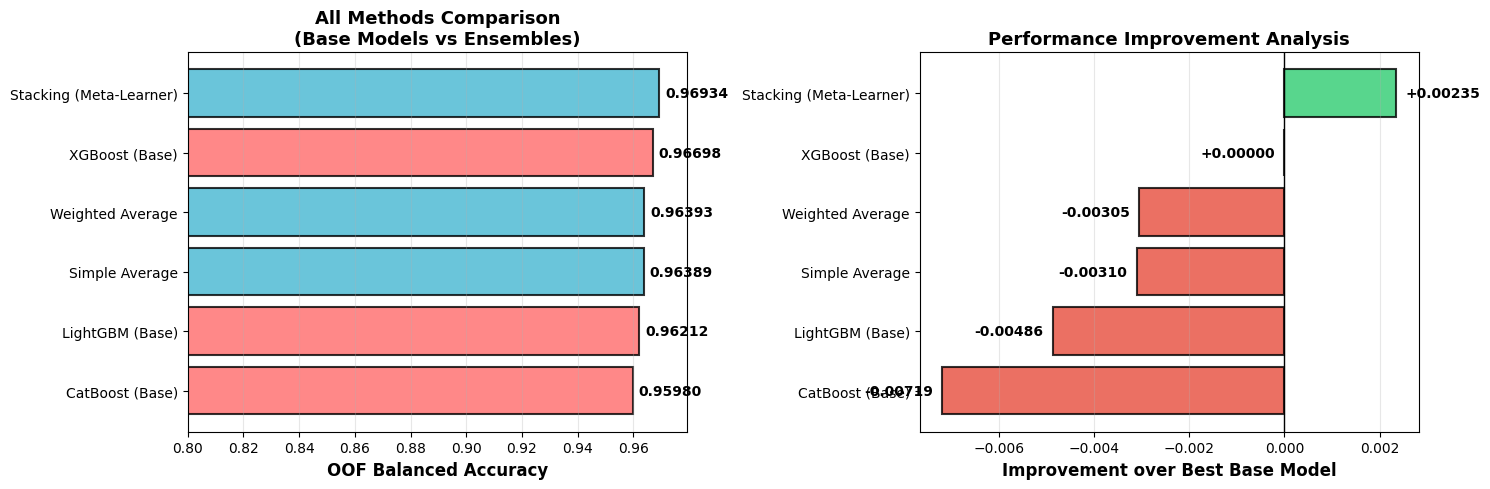

✓ Comparison visualization complete


In [29]:
# VISUALIZATION: ENSEMBLE METHODS COMPARISON

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Bar chart of all methods
ax1 = axes[0]
methods_list = comparison_df['Method'].tolist()
scores_list = comparison_df['OOF Balanced Accuracy'].tolist()
colors_methods = ['#FF6B6B' if 'Base' in t else '#45B7D1' for t in comparison_df['Type']]

bars = ax1.barh(methods_list, scores_list, color=colors_methods, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('OOF Balanced Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('All Methods Comparison\n(Base Models vs Ensembles)', fontsize=13, fontweight='bold')
ax1.set_xlim([0.80, max(scores_list) + 0.01])

# Add value labels
for i, (bar, score) in enumerate(zip(bars, scores_list)):
    ax1.text(score + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{score:.5f}', va='center', fontweight='bold', fontsize=10)

ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Plot 2: Improvement over best base model
ax2 = axes[1]
improvements = comparison_df['Improvement vs Best Base'].tolist()
colors_improvement = ['#2ECC71' if x > 0 else '#E74C3C' for x in improvements]

bars2 = ax2.barh(methods_list, improvements, color=colors_improvement, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Improvement over Best Base Model', fontsize=12, fontweight='bold')
ax2.set_title('Performance Improvement Analysis', fontsize=13, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Add value labels
for i, (bar, improvement) in enumerate(zip(bars2, improvements)):
    label = f'{improvement:+.5f}'
    x_pos = improvement + (0.0002 if improvement > 0 else -0.0002)
    ha = 'left' if improvement > 0 else 'right'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2, label, 
             va='center', ha=ha, fontweight='bold', fontsize=10)

ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("✓ Comparison visualization complete")

In [30]:
# DETAILED PER-CLASS METRICS COMPARISON

print("\n" + "="*70)
print("PER-CLASS PERFORMANCE METRICS FOR BEST METHODS")
print("="*70)

# Get predictions for detailed comparison
methods_detail = {
    'LightGBM': lgb_oof_preds.argmax(axis=1),
    'XGBoost': xgb_oof_preds.argmax(axis=1),
    'CatBoost': cat_oof_preds.argmax(axis=1),
    'Simple Average': simple_avg_pred,
    'Weighted Average': weighted_avg_pred,
    'Stacking': stacking_pred,
}

class_names = label_enc.classes_

for method_name, y_pred in methods_detail.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y, y_pred, labels=[0, 1, 2])
    
    print(f"\n{method_name}:")
    print(f"{'Class':<12} | {'Precision':<12} | {'Recall':<12} | {'F1-Score':<12}")
    print("-" * 55)
    for idx, class_name in enumerate(class_names):
        print(f"{class_name:<12} | {precision[idx]:<12.4f} | {recall[idx]:<12.4f} | {f1[idx]:<12.4f}")

# Summary of which methods excel at which classes
print("\n" + "="*70)
print("SUMMARY: BEST METHOD FOR EACH CLASS")
print("="*70)

class_best = {class_name: [] for class_name in class_names}

for method_name, y_pred in methods_detail.items():
    f1_scores = f1_score(y, y_pred, labels=[0, 1, 2], average=None)
    for idx, class_name in enumerate(class_names):
        class_best[class_name].append((method_name, f1_scores[idx]))

for class_name in class_names:
    best_method_for_class, best_f1 = max(class_best[class_name], key=lambda x: x[1])
    print(f"\n{class_name}: Best method is {best_method_for_class} (F1: {best_f1:.5f})")


PER-CLASS PERFORMANCE METRICS FOR BEST METHODS

LightGBM:
Class        | Precision    | Recall       | F1-Score    
-------------------------------------------------------
High         | 0.9639       | 0.9164       | 0.9396      
Low          | 0.9858       | 0.9952       | 0.9905      
Medium       | 0.9851       | 0.9748       | 0.9799      

XGBoost:
Class        | Precision    | Recall       | F1-Score    
-------------------------------------------------------
High         | 0.9335       | 0.9331       | 0.9333      
Low          | 0.9860       | 0.9955       | 0.9908      
Medium       | 0.9870       | 0.9723       | 0.9796      

CatBoost:
Class        | Precision    | Recall       | F1-Score    
-------------------------------------------------------
High         | 0.9667       | 0.9099       | 0.9375      
Low          | 0.9855       | 0.9948       | 0.9901      
Medium       | 0.9839       | 0.9747       | 0.9792      

Simple Average:
Class        | Precision    | Recall   

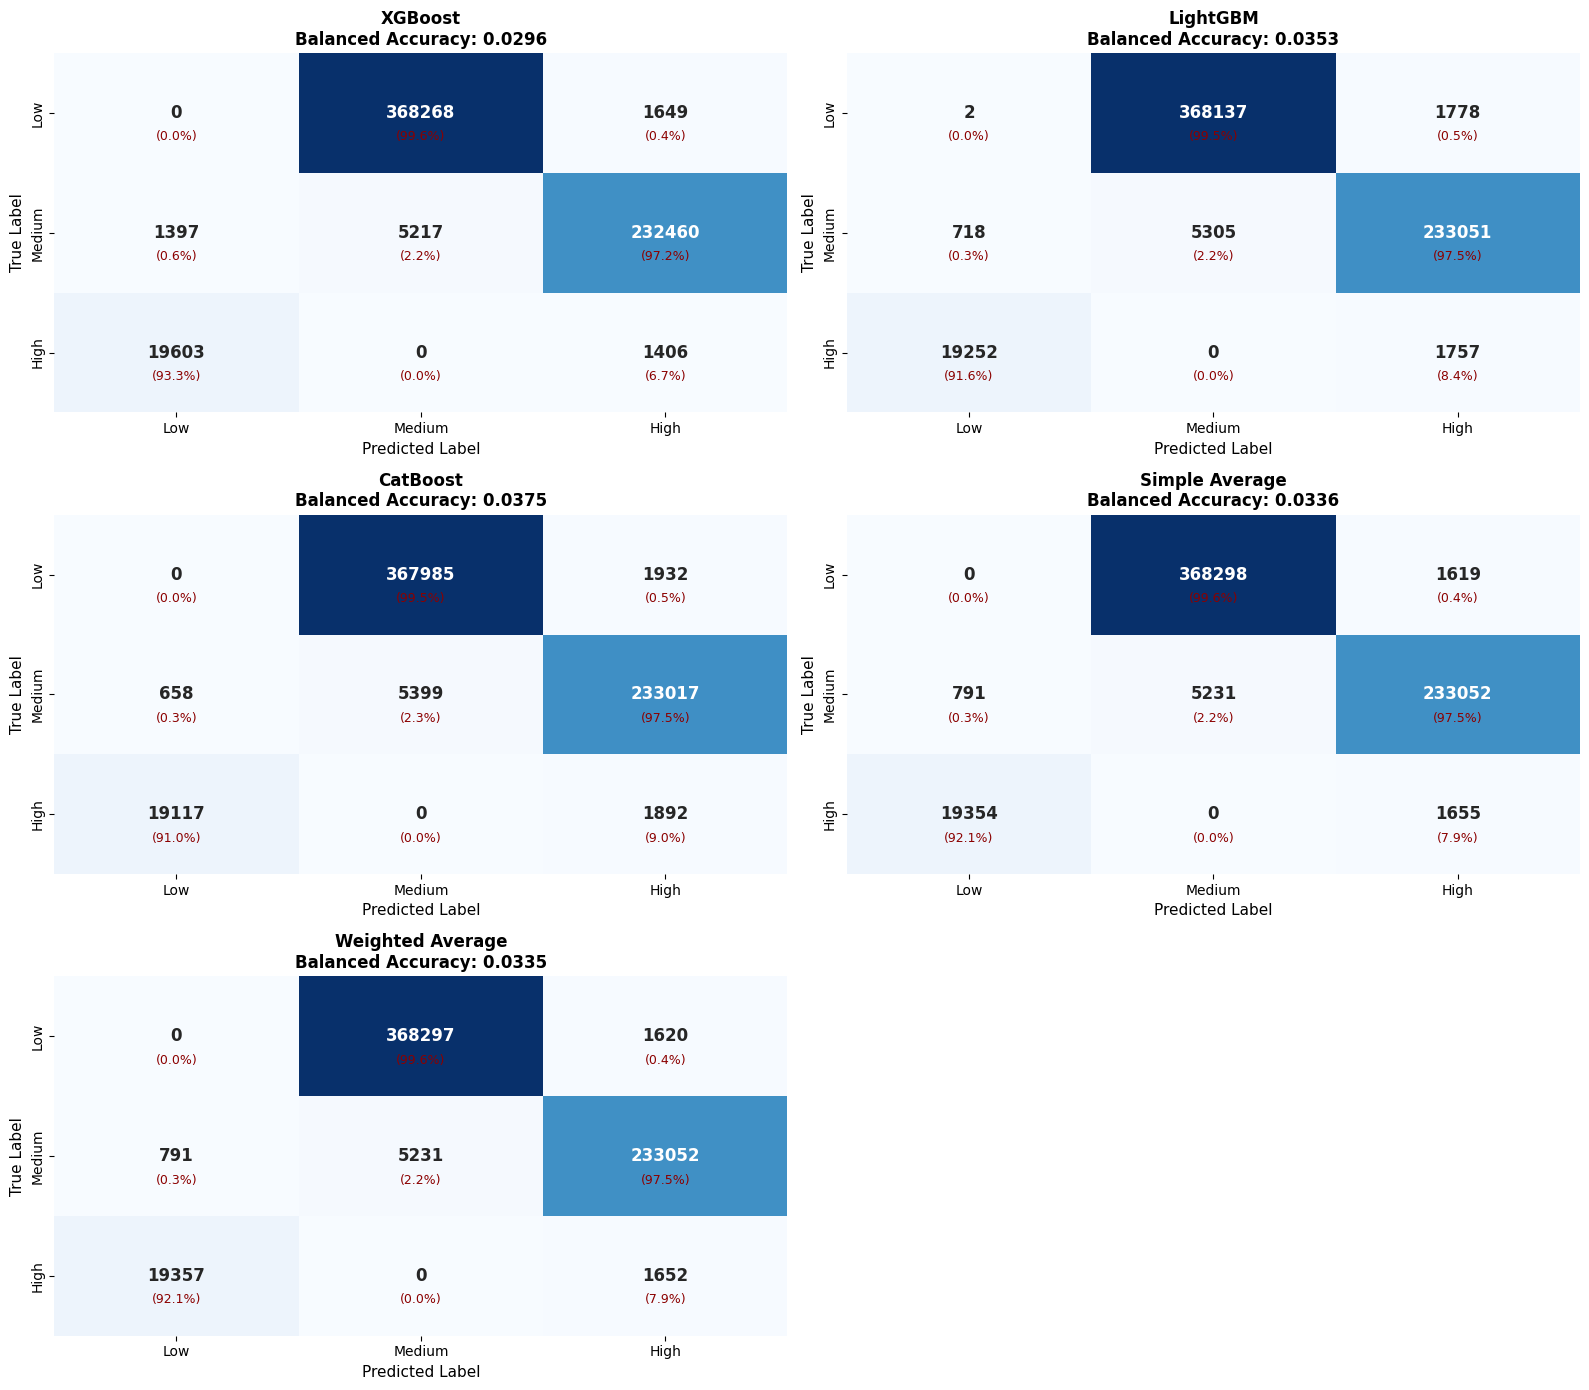

In [31]:
# Class labels mapping
class_labels = ['Low', 'Medium', 'High']

# Convert probability predictions to class labels (argmax)
def get_class_predictions(pred_array):
    """Convert probability predictions to class indices"""
    if pred_array.ndim == 1:
        # Already class indices
        return pred_array.astype(int)
    else:
        # Probability array - take argmax
        return np.argmax(pred_array, axis=1)

# Prepare OOF predictions for confusion matrices (as class labels)
individual_models = {
    'XGBoost': get_class_predictions(xgb_oof_preds),
    'LightGBM': get_class_predictions(lgb_oof_preds),
    'CatBoost': get_class_predictions(cat_oof_preds)
}

ensemble_methods = {
    'Simple Average': get_class_predictions(simple_avg_oof),
    'Weighted Average': get_class_predictions(weighted_avg_oof),
    'Stacking': get_class_predictions(meta_oof_preds)
}

all_predictions = {**individual_models, **ensemble_methods}

# Convert y_full to numeric labels if needed
y_full_labels = y_full.values if hasattr(y_full, 'values') else y_full
if y_full_labels.dtype == 'object':
    # Map string labels to indices
    y_full_labels = np.array([0 if x == 'Low' else (1 if x == 'Medium' else 2) for x in y_full_labels])
else:
    y_full_labels = y_full_labels.astype(int)

# Create comprehensive confusion matrix visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (model_name, predictions) in enumerate(all_predictions.items()):
    ax = axes[idx]
    
    # Compute confusion matrix
    cm = confusion_matrix(y_full_labels, predictions)
    
    # Normalize for visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        annot_kws={'fontsize': 12, 'weight': 'bold'},
        cbar_kws={'label': 'Count'}
    )
    
    # Add normalized values as text
    for i in range(3):
        for j in range(3):
            ax.text(j+0.5, i+0.7, f'({cm_normalized[i,j]:.1%})', 
                   ha='center', va='center', fontsize=9, color='darkred')
    
    balanced_acc = balanced_accuracy_score(y_full_labels, predictions)
    ax.set_title(f'{model_name}\nBalanced Accuracy: {balanced_acc:.4f}', fontsize=12, weight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

# Remove extra subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

In [32]:
# Detailed classification reports for all models
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

for model_name, predictions in all_predictions.items():
    print(f"\n{'─'*80}")
    print(f"📊 {model_name}")
    print(f"{'─'*80}")
    report = classification_report(y_full_labels, predictions, target_names=class_labels, digits=4)
    print(report)
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_full_labels, predictions)
    print(f"\nPer-Class Summary:")
    print(f"  {'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print(f"  {'-'*58}")
    for i, label in enumerate(class_labels):
        print(f"  {label:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
    
    balanced_acc = balanced_accuracy_score(y_full_labels, predictions)
    print(f"\n  Balanced Accuracy: {balanced_acc:.4f}")


DETAILED CLASSIFICATION REPORTS

────────────────────────────────────────────────────────────────────────────────
📊 XGBoost
────────────────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low     0.0000    0.0000    0.0000    369917
      Medium     0.0140    0.0218    0.0170    239074
        High     0.0060    0.0669    0.0110     21009

    accuracy                         0.0105    630000
   macro avg     0.0066    0.0296    0.0093    630000
weighted avg     0.0055    0.0105    0.0068    630000


Per-Class Summary:
  Class        Precision    Recall       F1-Score     Support   
  ----------------------------------------------------------
  Low          0.0000       0.0000       0.0000       369917    
  Medium       0.0140       0.0218       0.0170       239074    
  High         0.0060       0.0669       0.0110       21009     

  Balanced Accuracy: 0.0296

──────────────────────────────────────────

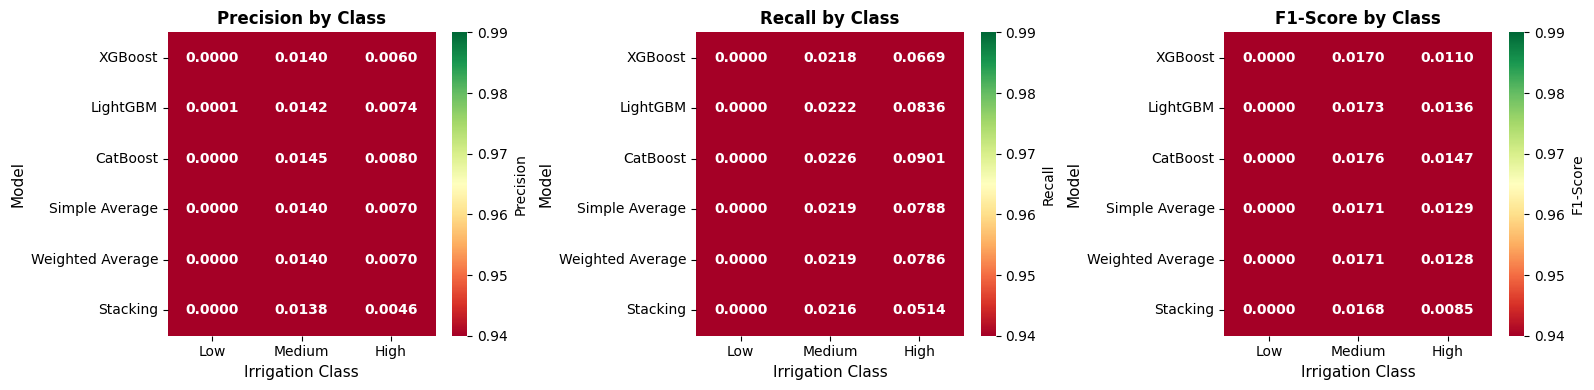

In [33]:
# Per-Class Performance Heatmap (Precision, Recall, F1-Score)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = ['Precision', 'Recall', 'F1-Score']
metric_data = []

# Collect metrics for each model
for model_name, predictions in all_predictions.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_full_labels, predictions)
    metric_data.append({
        'Model': model_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Create heatmaps for each metric
for metric_idx, metric_name in enumerate(metrics):
    data_matrix = np.array([md[metric_name] for md in metric_data])
    
    sns.heatmap(
        data_matrix,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn',
        vmin=0.94,
        vmax=0.99,
        xticklabels=class_labels,
        yticklabels=[md['Model'] for md in metric_data],
        ax=axes[metric_idx],
        cbar_kws={'label': metric_name},
        annot_kws={'fontsize': 10, 'weight': 'bold'}
    )
    axes[metric_idx].set_title(f'{metric_name} by Class', fontsize=12, weight='bold')
    axes[metric_idx].set_ylabel('Model', fontsize=11)
    axes[metric_idx].set_xlabel('Irrigation Class', fontsize=11)

plt.tight_layout()
plt.show()

## 11. Final Predictions & Submission

Generate test set predictions using optimal stacking ensemble  

In [34]:
# FINAL SUBMISSION WITH BEST ENSEMBLE METHOD (STACKING)

print("\n" + "="*70)
print("GENERATING FINAL SUBMISSION WITH STACKING ENSEMBLE")
print("="*70)

print(f"\nBest Ensemble Method: Stacking (Meta-Learner)")
print(f"  OOF Balanced Accuracy: {stacking_score:.5f}")
print(f"  Improvement over XGBoost: +{improvement_single_stack:.5f}")

# Use stacking test predictions as final predictions
final_submission_preds = meta_test_preds

# Get predicted classes (argmax)
y_test_pred = final_submission_preds.argmax(axis=1)

# Inverse transform back to original class labels
y_test_labels = label_enc.inverse_transform(y_test_pred)

# Create submission dataframe
submission = pd.DataFrame({
    'id': test['id'].values,
    'Irrigation_Need': y_test_labels
})

print(f"\n✓ Submission Statistics:")
print(f"  Shape: {submission.shape}")
print(f"  Class Distribution:")
class_dist = submission['Irrigation_Need'].value_counts()
for cls, count in class_dist.items():
    pct = (count / len(submission)) * 100
    print(f"    {cls:>6}: {count:>7} ({pct:>5.2f}%)")

# Save submission file
submission_path = '/kaggle/working/submission.csv'
submission.to_csv(submission_path, index=False)
print(f"\n✓ Submission saved to: {submission_path}")


GENERATING FINAL SUBMISSION WITH STACKING ENSEMBLE

Best Ensemble Method: Stacking (Meta-Learner)
  OOF Balanced Accuracy: 0.96934
  Improvement over XGBoost: +0.00235

✓ Submission Statistics:
  Shape: (270000, 2)
  Class Distribution:
       Low:  159786 (59.18%)
    Medium:  100188 (37.11%)
      High:   10026 ( 3.71%)

✓ Submission saved to: /kaggle/working/submission.csv


do give an upvote if useful (✿◠‿◠)